# Data
data.py

In [1]:
import torch
from torch.utils.data import Dataset

class SyntheticLogReturnsDataset(Dataset):
    def __init__(self, n_stock, t, window, distribution='normal', 
                 overlapping_windows=False, task='reconstruction', seed=42):
        """
        Synthetic log returns dataset for financial modeling.
        
        Args:
            n_stock: Number of stocks
            t: Number of time windows
            window: Window size (lookback period)
            distribution: 'normal' or 't' (Student's t)
            overlapping_windows: If False, windows don't overlap. If True, they do.
            task: 'reconstruction' or 'prediction'
            seed: Random seed for reproducibility
        """
        self.n_stock = n_stock
        self.t = t
        self.window = window
        self.distribution = distribution
        self.overlapping_windows = overlapping_windows
        self.task = task
        self.seed = seed
        
        self._generate_data()
    
    def _generate_data(self):
        """Generate synthetic returns data with market factor structure."""
        torch.manual_seed(self.seed)
        
        # Calculate total time points needed
        if self.overlapping_windows:
            t_total = self.t + self.window - 1
        else:
            t_total = self.t * self.window
        
        # Add extra point for prediction task
        if self.task == 'prediction':
            t_total += 1
        
        # Generate market returns (SPY 20-year statistics: mean=0.0003, std=0.0122)
        self.r_market = self._sample_distribution(t_total, mean=0.0003, std=0.0122)
        
        # Generate stock-specific parameters
        self.alphas = torch.randn(self.n_stock) * 0.005
        self.betas = torch.randn(self.n_stock) * 0.3 + 1.0
        self.idio_vols = torch.rand(self.n_stock) * 0.015 + 0.005
        
        # Generate stock returns: r_i,t = alpha_i + beta_i * r_market,t + epsilon_i,t
        systematic = self.alphas.unsqueeze(1) + self.betas.unsqueeze(1) * self.r_market.unsqueeze(0)
        idiosyncratic = self._sample_distribution((self.n_stock, t_total)) * self.idio_vols.unsqueeze(1)
        self.returns = systematic + idiosyncratic  # Shape: (n_stock, t_total)
    
    def _sample_distribution(self, shape, mean=0.0, std=1.0):
        """Sample from specified distribution."""
        if self.distribution == 'normal':
            return torch.randn(shape) * std + mean
        elif self.distribution == 't':
            df = 5.0
            dist = torch.distributions.studentT.StudentT(df=df)
            samples = dist.sample(shape if isinstance(shape, tuple) else (shape,))
            # Adjust for Student's t variance: Var(T_df) = df/(df-2) for df > 2
            scale_factor = (df / (df - 2)) ** 0.5
            return samples * (std / scale_factor) + mean
        else:
            raise ValueError(f"Unknown distribution: {distribution}")
    
    def __len__(self):
        """Total number of samples: n_stock * t windows."""
        return self.n_stock * self.t
    
    def __getitem__(self, idx):
        """
        Get a single stock-window sample.
        
        Returns dict with keys: 'stock_returns', 'r_market', 'target'
        For prediction task, also includes 'r_market_next'
        """
        # Decode flat index into stock and window indices
        stock_idx = idx % self.n_stock
        window_idx = idx // self.n_stock
        
        # Calculate time range for this window
        if self.overlapping_windows:
            start_t = window_idx
            end_t = window_idx + self.window
        else:
            start_t = window_idx * self.window
            end_t = (window_idx + 1) * self.window
        
        # Extract stock returns and market returns for window
        stock_returns = self.returns[stock_idx, start_t:end_t]
        r_market = self.r_market[start_t:end_t]
        
        if self.task == 'reconstruction':
            return {
                'stock_returns': stock_returns,
                'r_market': r_market,
                'target': stock_returns  # Reconstruct the input
            }
        else:  # prediction
            next_return = self.returns[stock_idx, end_t]
            r_market_next = self.r_market[end_t]
            
            return {
                'stock_returns': stock_returns,
                'r_market': r_market,
                'r_market_next': r_market_next,
                'target': next_return
            }

def generate_datasets(config):
    seed_start = config['SEED']
    seed_end   = seed_start + config['N_DATASET_TRAIN']
    
    train_datasets = [
        SyntheticLogReturnsDataset(
            n_stock        = config['N_STOCK'],
            t              = config['T'],
            window         = config['WINDOW'],
            distribution   = config['DISTRIBUTION'],
            task           = config['TASK'],
            overlapping_windows=False,
            seed           = seed
        ) for seed in range(seed_start, seed_end)
    ]
    
    seed_start = seed_end
    seed_end   = seed_start + config['N_DATASET_VAL']
    
    val_datasets = [
        SyntheticLogReturnsDataset(
            n_stock        = config['N_STOCK'],
            t              = config['T'],
            window         = config['WINDOW'],
            distribution   = config['DISTRIBUTION'],
            task           = config['TASK'],
            overlapping_windows=False,
            seed           = seed
        ) for seed in range(seed_start, seed_end)
    ]
    
    seed_start = seed_end
    seed_end   = seed_start + config['N_DATASET_TEST']
    
    test_datasets = [
        SyntheticLogReturnsDataset(
            n_stock        = config['N_STOCK'],
            t              = config['T'],
            window         = config['WINDOW'],
            distribution   = config['DISTRIBUTION'],
            task           = config['TASK'],
            overlapping_windows=False,
            seed           = seed
        ) for seed in range(seed_start, seed_end)
    ]

    return train_datasets, val_datasets, test_datasets

# Model
model.py

In [2]:
import torch
import torch.nn as nn
from typing import Tuple, Optional

class FinancialLSTM(nn.Module):
    
    def __init__(
        self, 
        window: int,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
        task: str = 'reconstruction'
    ):
        super(FinancialLSTM, self).__init__()
        
        self.window = window
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.task = task
        
        self.lstm = nn.LSTM(
            input_size=3,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        self.alpha_head = nn.Linear(hidden_size, 1)
        self.beta_head = nn.Linear(hidden_size, 1)
    
    def forward(
        self,
        stock_returns: torch.Tensor,
        r_market: torch.Tensor,
        r_market_next: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        
        interaction = stock_returns * r_market
        lstm_input = torch.stack([stock_returns, r_market, interaction], dim=-1)
        
        lstm_out, _ = self.lstm(lstm_input)
        final_hidden = lstm_out[:, -1, :]
        
        alpha = self.alpha_head(final_hidden).squeeze(-1)
        beta = self.beta_head(final_hidden).squeeze(-1)
        
        if self.task == 'reconstruction':
            reconstruction = alpha.unsqueeze(-1) + beta.unsqueeze(-1) * r_market
        else:
            if r_market_next is None:
                raise ValueError("r_market_next required for prediction task")
            reconstruction = alpha + beta * r_market_next.squeeze(-1)
        
        return reconstruction, alpha, beta

## Lightning trainer

In [106]:
import lightning.pytorch as pl

class FinancialLSTMModule(pl.LightningModule):
    
    def __init__(
        self,
        window: int,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.2,
        task: str = 'reconstruction',
        lr: float = 1e-3
    ):
        super().__init__()
        self.save_hyperparameters()
        
        self.model = FinancialLSTM(window, hidden_size, num_layers, dropout, task)
        self.task = task
        
    def forward(self, stock_returns, r_market, r_market_next=None):
        return self.model(stock_returns, r_market, r_market_next)
    
    def _shared_step(self, batch, batch_idx):
        stock_returns = batch['stock_returns']
        r_market = batch['r_market']
        target = batch['target']
        
        if self.task == 'prediction':
            r_market_next = batch['r_market_next']
            reconstruction, alpha, beta = self(stock_returns, r_market, r_market_next)
        else:
            reconstruction, alpha, beta = self(stock_returns, r_market)
        
        loss = nn.functional.mse_loss(reconstruction, target)
        return loss, reconstruction, alpha, beta
    
    def training_step(self, batch, batch_idx):
        loss, _, _, _ = self._shared_step(batch, batch_idx)
        self.log('train_loss', loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss, _, _, _ = self._shared_step(batch, batch_idx)
        self.log('val_loss', loss)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# Main
main.py

In [4]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger

In [ ]:
config = {
    'N_DATASET_TRAIN': 100,
    'N_DATASET_VAL': 20,
    'N_DATASET_TEST': 10,
    'N_STOCK': 4,
    'T': 250,
    'WINDOW': 60,
    'TASK': 'reconstruction',
    'HIDDEN_SIZE': 64,
    'BATCH_SIZE': 1,
    'NUM_EPOCHS': 10,
    'LEARNING_RATE': 1e-4,
    'SHUFFLE_BATCHES': True,
    'DROPOUT': 0.2,
    'PATIENCE': 3,
    'DISTRIBUTION': 'normal',
    'SEED': 45
}

train_datasets, val_datasets, test_datasets = generate_datasets(config)

train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=config['BATCH_SIZE'], shuffle=config['SHUFFLE_BATCHES'])
val_loader   = DataLoader(ConcatDataset(val_datasets),   batch_size=config['BATCH_SIZE'], shuffle=False)
test_loader  = DataLoader(ConcatDataset(test_datasets),  batch_size=1, shuffle=False)

model = FinancialLSTMModule(
    window = config['WINDOW'],
    hidden_size = config['HIDDEN_SIZE'],
    dropout = config['DROPOUT']
)

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00,
    patience=config['PATIENCE'],
    verbose=False,
    mode='min'
)

tb_logger = TensorBoardLogger(
    save_dir='logs/',
    name='financial_lstm',
    version='initial_run_estimation'
)

trainer = Trainer(
    max_epochs=config['NUM_EPOCHS'],
    callbacks=[early_stop_callback],
    logger=tb_logger
)

# Train model
start_time = time.time()

trainer.fit(model, train_loader, val_loader)

print(f"Done! Trained model in {time.time() - start_time:>7f} seconds!")

# Benchmark

In [50]:
from scipy import stats

def OLS_on_sample(stock_returns, r_market, r_market_next=None):
    beta, alpha, _, _, _ = stats.linregress(r_market, stock_returns)
    
    if r_market_next is None:
        reconstruction = alpha + beta * r_market
    else:
        reconstruction = alpha + beta * r_market_next.squeeze(-1)

    return reconstruction, alpha, beta

In [54]:
true_alphas = torch.stack([test_dataset.alphas for test_dataset in test_datasets])
true_betas  = torch.stack([test_dataset.betas for test_dataset in test_datasets])

loss_function = nn.MSELoss(reduction='mean')

model_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

ols_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

n_stock = config['N_STOCK']
len_dataset = n_stock * config['T']

start_time = time.time()
print("Evauating model on test set...")

model.eval()
with torch.no_grad():
    for i, data in enumerate(test_loader):
        curr_dataset = i // len_dataset
        curr_stock = i % n_stock

        true_alpha = true_alphas[curr_dataset, curr_stock]
        true_beta  = true_betas[curr_dataset, curr_stock]

        stock_returns = data['stock_returns']
        r_market      = data['r_market']
        target        = data['target']

        if config['TASK'] == 'prediction':
            r_market_next = data['r_market_next']
        else:
            r_market_next = None
        
        # Model loss
        reconstruction, alpha, beta = model(stock_returns, r_market, r_market_next)
        model_summary['recon_loss'].append(loss_function(reconstruction, target).item())
        model_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        model_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        model_summary['alpha'].append(alpha.detach())
        model_summary['beta'].append(beta.detach())

        
        #OLS and OLS loss
        stock_returns = stock_returns.squeeze()
        r_market      = r_market.squeeze()
        target        = target.squeeze()

        if config['TASK'] == 'prediction':
            r_market_next = r_market_next.squeeze()
        
        reconstruction, alpha, beta = OLS_on_sample(stock_returns, r_market, r_market_next)
        alpha, beta = torch.Tensor([alpha]), torch.Tensor([beta])
        ols_summary['recon_loss'].append(loss_function(reconstruction, target).item())
        ols_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        ols_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        ols_summary['alpha'].append(alpha)
        ols_summary['beta'].append(beta)

model_summary['alpha'] = torch.Tensor(model_summary['alpha']).reshape(config['N_DATASET_TEST'], config['T'], config['N_STOCK'])
model_summary['beta'] = torch.Tensor(model_summary['beta']).reshape(config['N_DATASET_TEST'], config['T'], config['N_STOCK'])

ols_summary['alpha'] = torch.Tensor(ols_summary['alpha']).reshape(config['N_DATASET_TEST'], config['T'], config['N_STOCK'])
ols_summary['beta'] = torch.Tensor(ols_summary['beta']).reshape(config['N_DATASET_TEST'], config['T'], config['N_STOCK'])

print(f"Done! time={time.time() - start_time:>7f} seconds")

In [ ]:
# Calculate test metrics for hp_metric
model_test_loss = np.mean(model_summary['recon_loss'])
ols_test_loss = np.mean(ols_summary['recon_loss'])

# Log hp_metric (model_test_loss)
tb_logger.log_hyperparams(
    params=config,
    metrics={'hp_metric': model_test_loss}
)

tb_logger.experiment.add_scalar('test/model_alpha_loss', model_alpha_test_loss)
tb_logger.experiment.add_scalar('test/model_beta_loss', model_beta_test_loss)

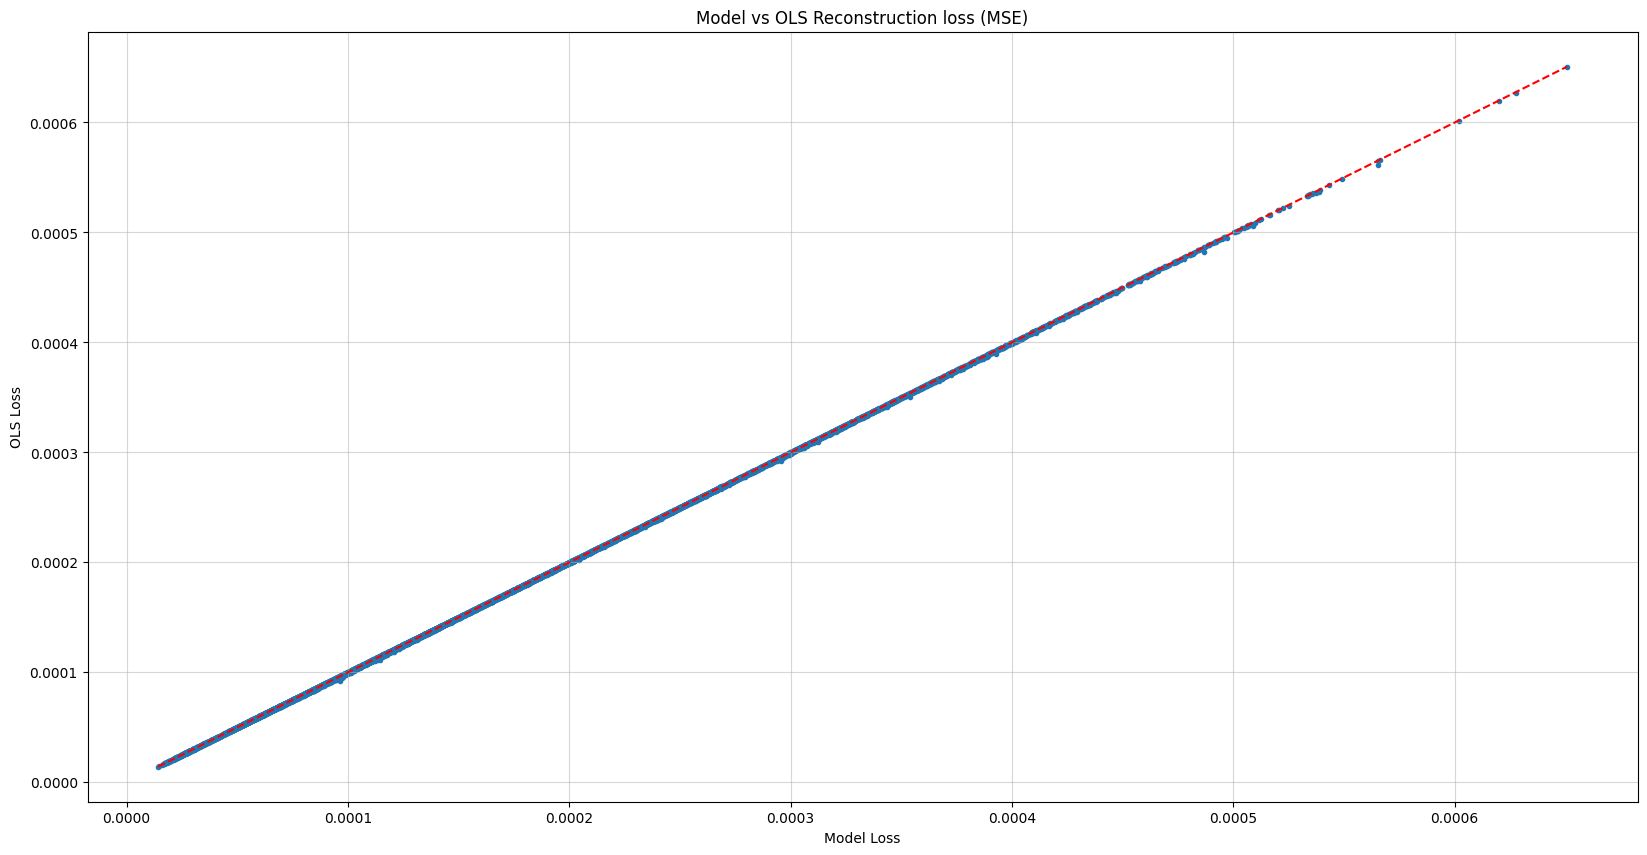

In [75]:
plt.figure(figsize=(20, 10))

plt.scatter(model_summary['recon_loss'], ols_summary['recon_loss'], marker='.')
plt.xlabel('Model Loss')
plt.ylabel('OLS Loss')

identity = np.linspace(min(ols_summary['recon_loss']), max(ols_summary['recon_loss']), 1000)
plt.plot(identity, identity, 'r--')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE)', plt.gcf())
plt.show()

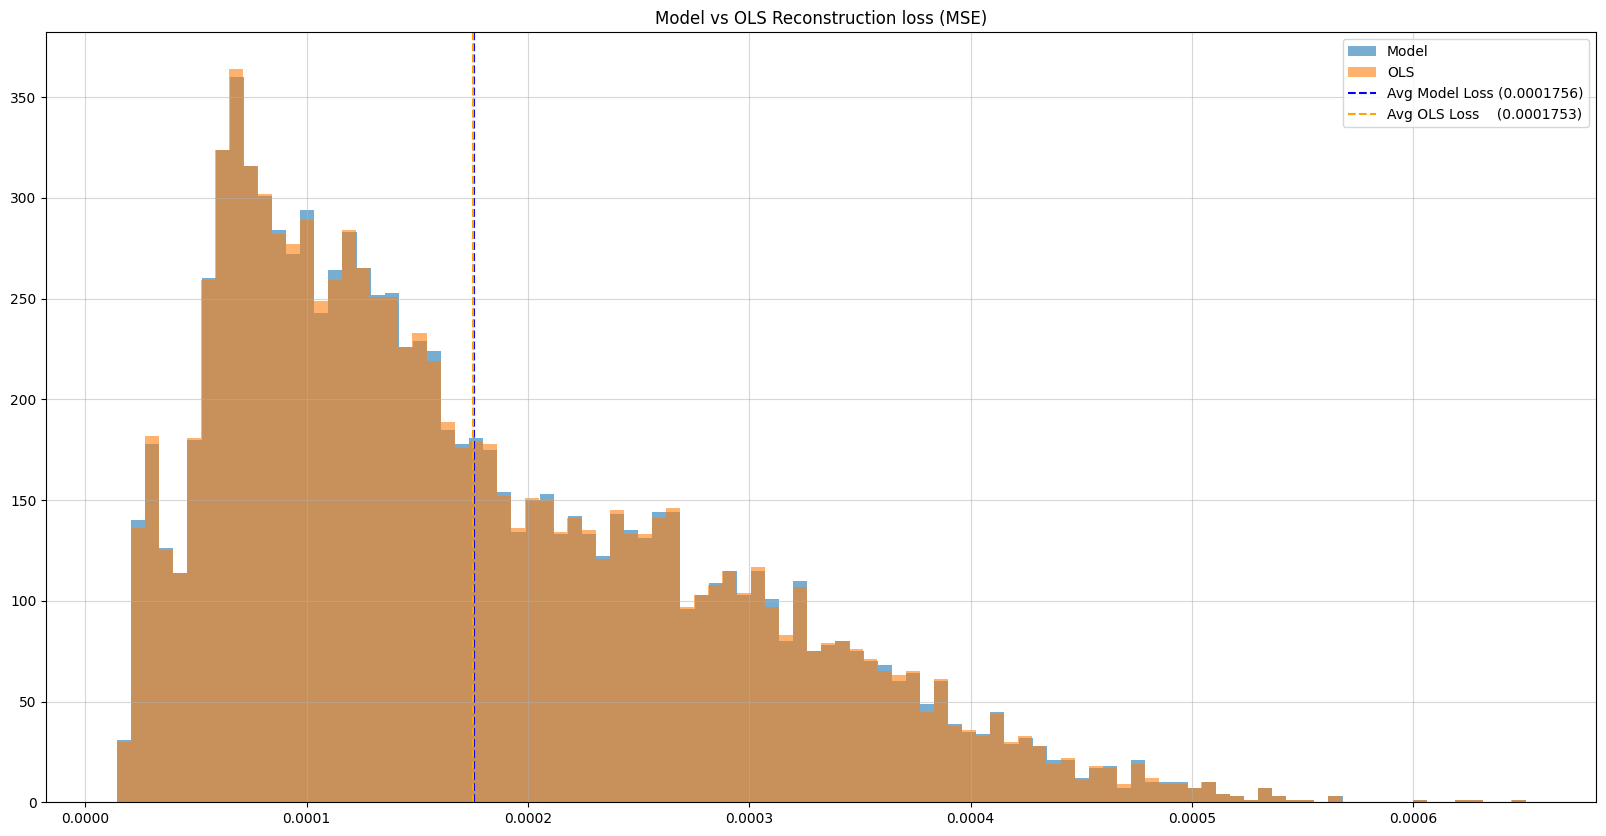

In [105]:
plt.figure(figsize=(20, 10))

plt.hist(model_summary['recon_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['recon_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_test_loss:.7f})')
plt.axvline(ols_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_test_loss:.7f})')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Reconstruction loss (MSE) Histogram', plt.gcf())
plt.show()

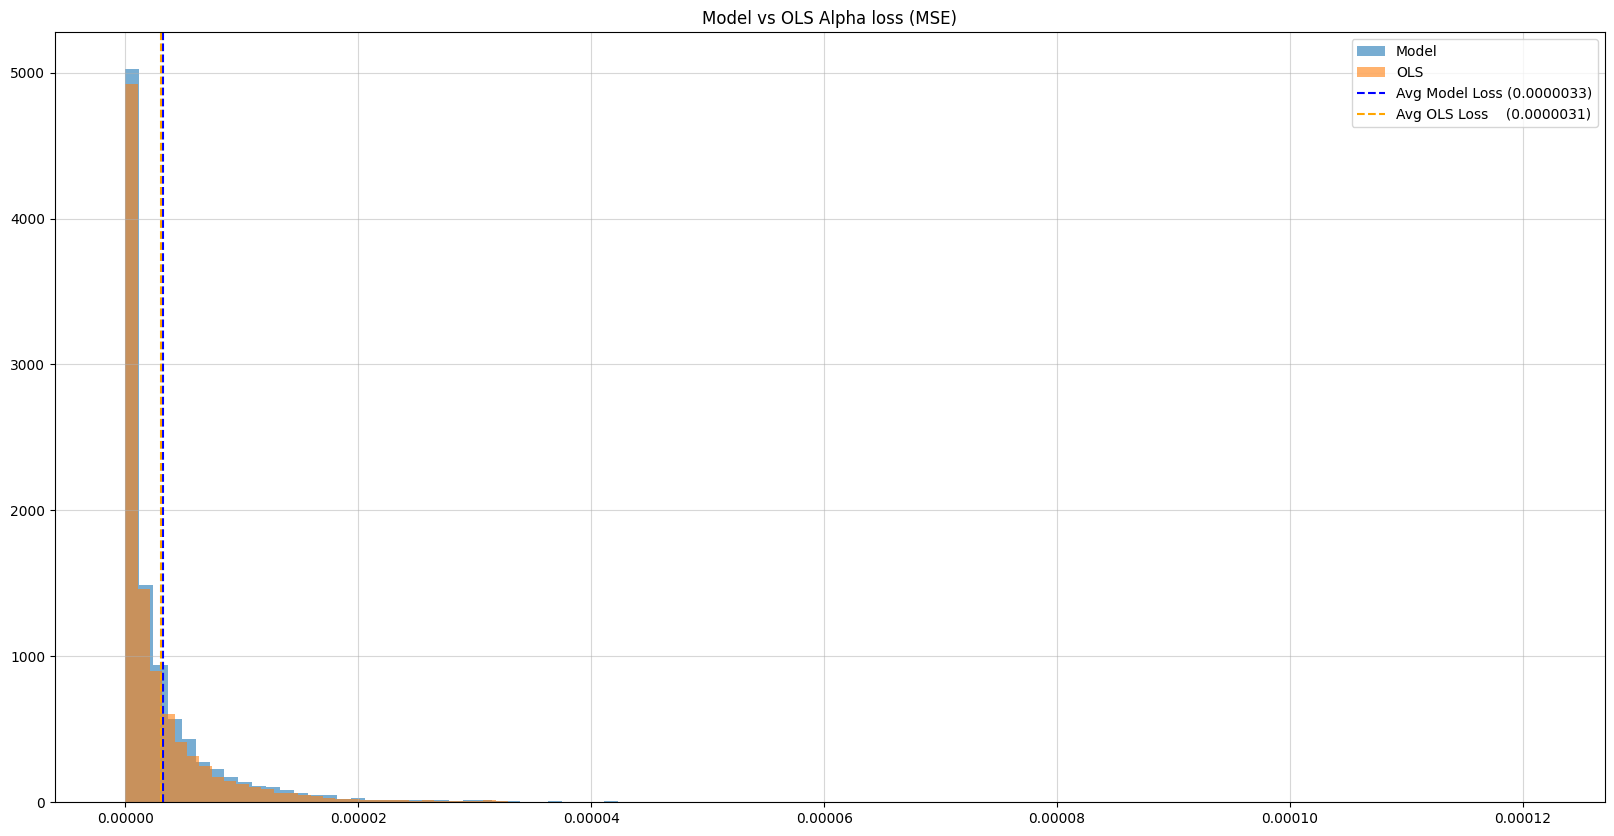

In [78]:
model_alpha_test_loss = np.mean(model_summary['alpha_loss'])
ols_alpha_test_loss = np.mean(ols_summary['alpha_loss'])

plt.figure(figsize=(20, 10))

plt.hist(model_summary['alpha_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['alpha_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_alpha_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_alpha_test_loss:.7f})')
plt.axvline(ols_alpha_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_alpha_test_loss:.7f})')

plt.title('Model vs OLS Alpha loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Alpha loss (MSE)', plt.gcf())
plt.show()

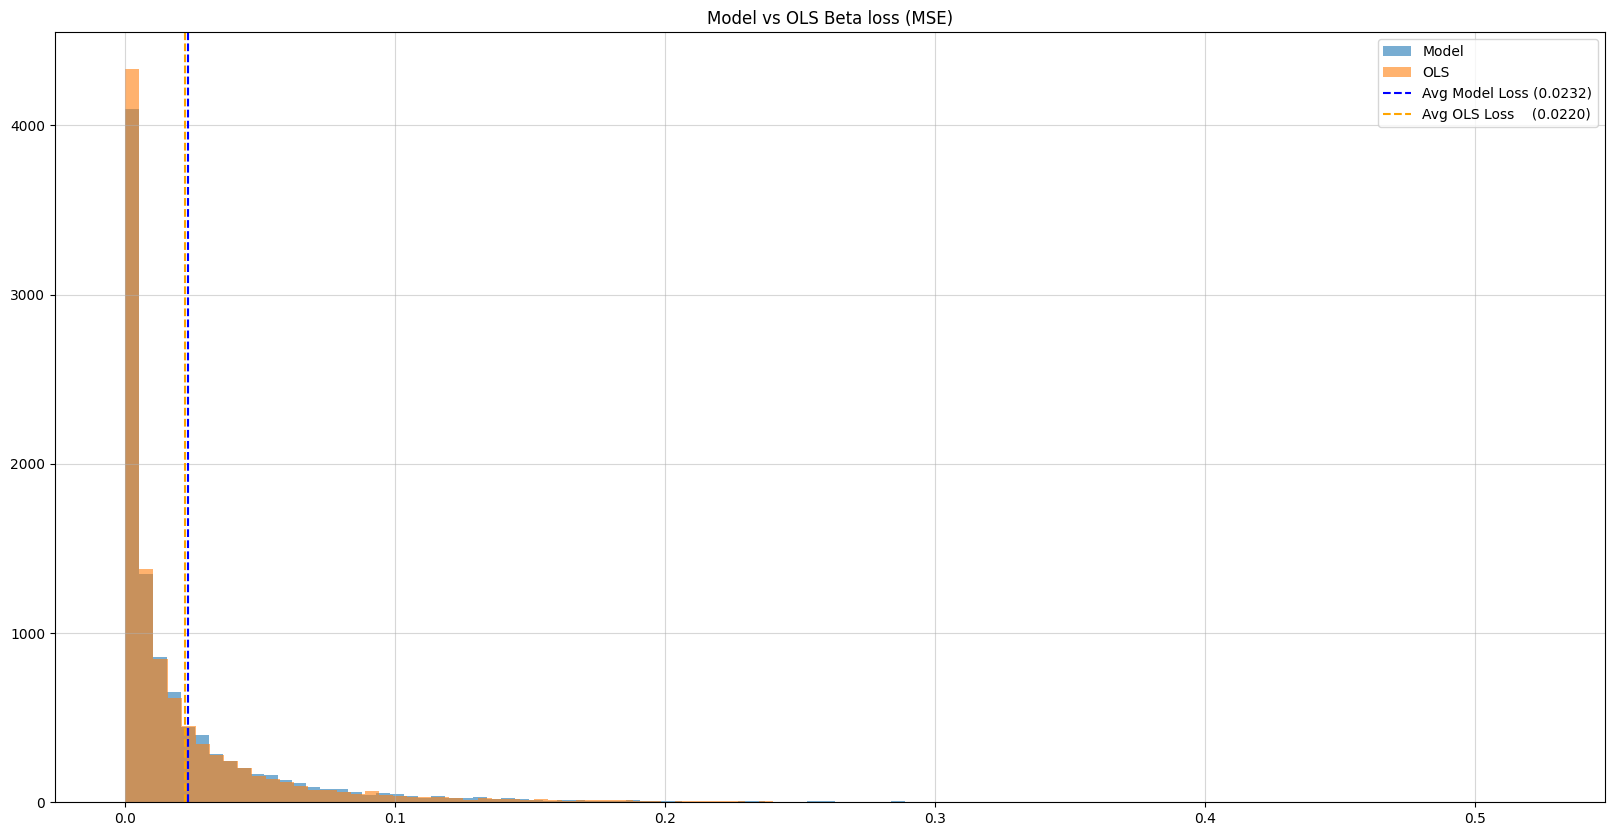

In [69]:
model_beta_test_loss = np.mean(model_summary['beta_loss'])
ols_beta_test_loss = np.mean(ols_summary['beta_loss'])

plt.figure(figsize=(20, 10))

plt.hist(model_summary['beta_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['beta_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_beta_test_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_beta_test_loss:.4f})')
plt.axvline(ols_beta_test_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_beta_test_loss:.4f})')

plt.title('Model vs OLS Beta loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Beta loss (MSE)', plt.gcf())
plt.show()

In [111]:
idxs = list(range(16))

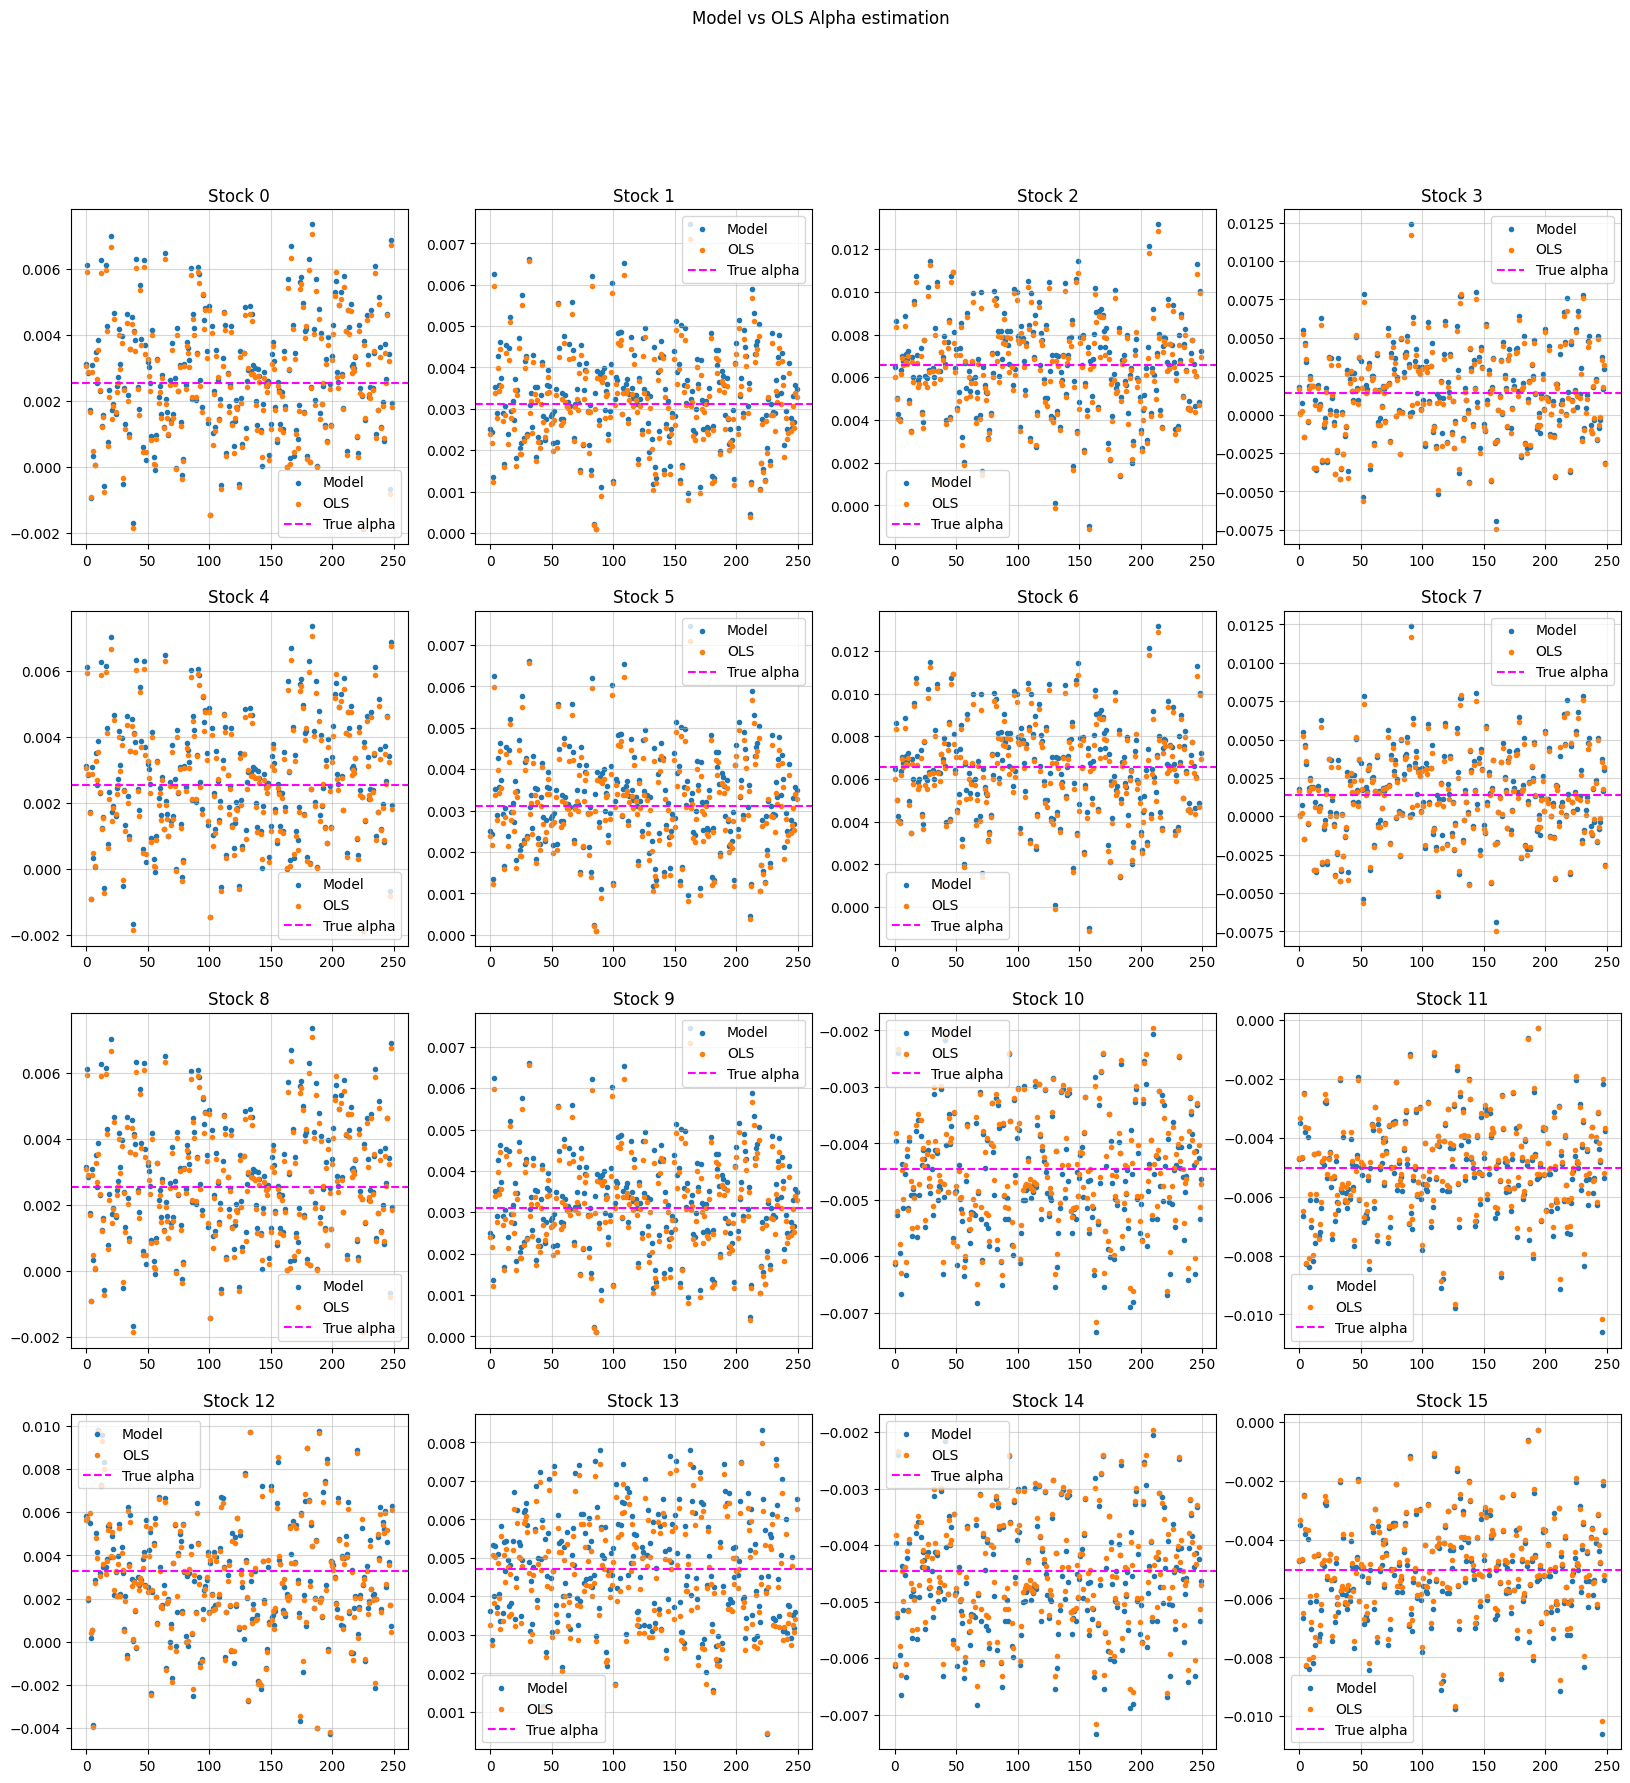

In [112]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Model vs OLS Alpha estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_DATASET_TEST']
    
    true_alpha  = true_alphas[dataset_idx, stock_idx]
    model_alpha = model_summary['alpha'][dataset_idx, :, stock_idx]
    ols_alpha   = ols_summary['alpha'][dataset_idx, :, stock_idx]

    sample = np.arange(len(model_alpha))

    ax.set_title(f'Stock {idx}')
    ax.scatter(sample, model_alpha, label='Model', marker='.')
    ax.scatter(sample, ols_alpha, label='OLS', marker='.')
    ax.axhline(true_alpha, color='magenta', linestyle='--', label='True alpha')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Alpha estimation', fig)
plt.show()

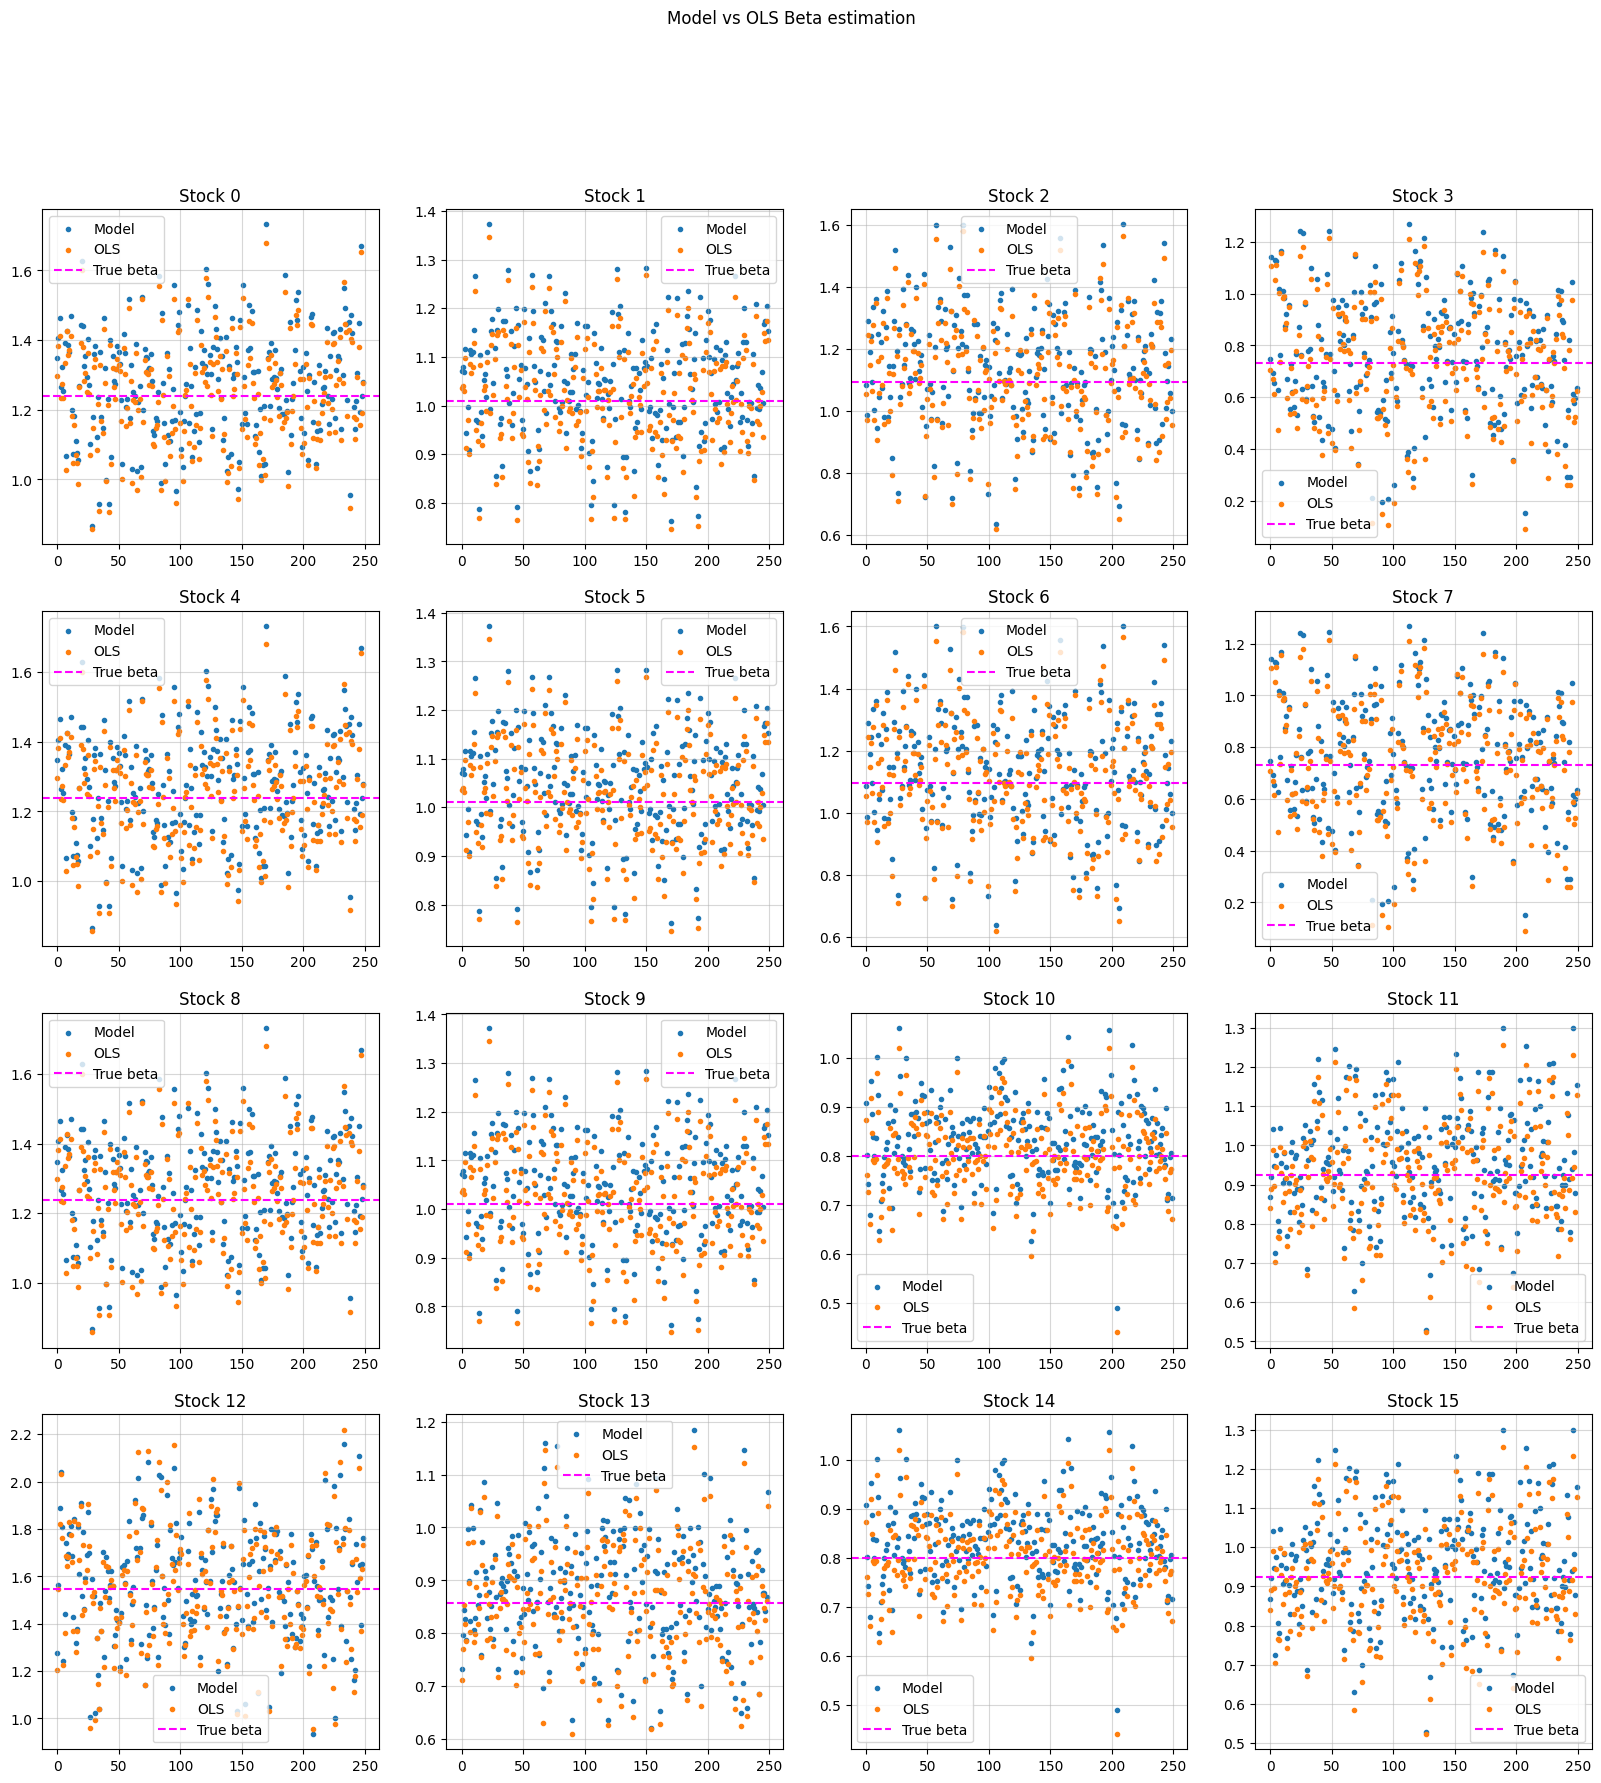

In [113]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Model vs OLS Beta estimation')

axs = axs.flatten()

for ax, idx in zip(axs, idxs):
    stock_idx   = idx % config['N_STOCK']
    dataset_idx = idx // config['N_DATASET_TEST']
    
    true_beta  = true_betas[dataset_idx, stock_idx]
    model_beta = model_summary['beta'][dataset_idx, :, stock_idx]
    ols_beta   = ols_summary['beta'][dataset_idx, :, stock_idx]

    sample = np.arange(len(model_beta))

    ax.set_title(f'Stock {idx}')
    ax.scatter(sample, model_beta, label='Model', marker='.')
    ax.scatter(sample, ols_beta, label='OLS', marker='.')
    ax.axhline(true_beta, color='magenta', linestyle='--', label='True beta')

    ax.legend()
    ax.grid(alpha=0.5)

# Log to TensorBoard
tb_logger.experiment.add_figure('Model vs OLS Beta estimation', fig)
plt.show()